In [45]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [46]:
classes = np.array([0,1])

In [47]:
record_inputs_at_a_time_to_load_into_ram = 50000

In [48]:
def build_model(hidden_neurons,activation, solver, max_iter):
    model = MLPClassifier(hidden_layer_sizes = hidden_neurons,
                         activation = activation, 
                         solver = solver ,
                         max_iter = max_iter,
                         learning_rate_init = 0.001,
                         alpha = 0.000001,
                         random_state = 42
    
    )
    return model

In [49]:
def training_the_model(model,X,y):
    model.partial_fit(X,y,classes = classes)
    return model

In [50]:
def model_score(model,X,y):
    accuracy = model.score(X,y)
    predictions = model.predict(X) 
    print(f"Accuracy:{accuracy*100:.2f}%") 
    print("Predictions:", predictions) 
    return accuracy, predictions

In [51]:
mlp_model_intilization = build_model(hidden_neurons = (400,200,100), activation = 'relu',solver = 'adam',max_iter = 2000 ) 
scaler = StandardScaler()

In [42]:
for data_chunk_value, chunk in enumerate(pd.read_csv('HIGGS.csv.gz', chunksize = record_inputs_at_a_time_to_load_into_ram,header = None, compression = 'gzip')):
    x_val = chunk.iloc[:, 1:]
    y_val = chunk.iloc[:,0]
    scaler.partial_fit(x_val) 
    x_val_scaled = scaler.transform(x_val)
    mlp_model_training = training_the_model(mlp_model_intilization,x_val_scaled,y_val) 
    print(f"Processed Chunk {data_chunk_value + 1} ({record_inputs_at_a_time_to_load_into_ram} rows)")
    model_score(mlp_model_training, x_val_scaled, y_val)
    print("-"*30)
    if data_chunk_value == 220:
        break

Processed Chunk 1 (50000 rows)
Accuracy:74.32%
Predictions: [1 1 1 ... 0 1 0]
------------------------------
Processed Chunk 2 (50000 rows)
Accuracy:74.48%
Predictions: [0 0 1 ... 1 0 0]
------------------------------
Processed Chunk 3 (50000 rows)
Accuracy:74.55%
Predictions: [0 1 1 ... 1 1 1]
------------------------------
Processed Chunk 4 (50000 rows)
Accuracy:74.80%
Predictions: [1 1 1 ... 1 1 1]
------------------------------
Processed Chunk 5 (50000 rows)
Accuracy:74.81%
Predictions: [1 0 0 ... 1 1 0]
------------------------------
Processed Chunk 6 (50000 rows)
Accuracy:75.50%
Predictions: [1 0 1 ... 0 1 1]
------------------------------
Processed Chunk 7 (50000 rows)
Accuracy:75.45%
Predictions: [0 1 0 ... 0 1 1]
------------------------------
Processed Chunk 8 (50000 rows)
Accuracy:75.09%
Predictions: [1 0 1 ... 1 1 0]
------------------------------
Processed Chunk 9 (50000 rows)
Accuracy:75.01%
Predictions: [0 0 1 ... 1 1 0]
------------------------------
Processed Chunk 10 

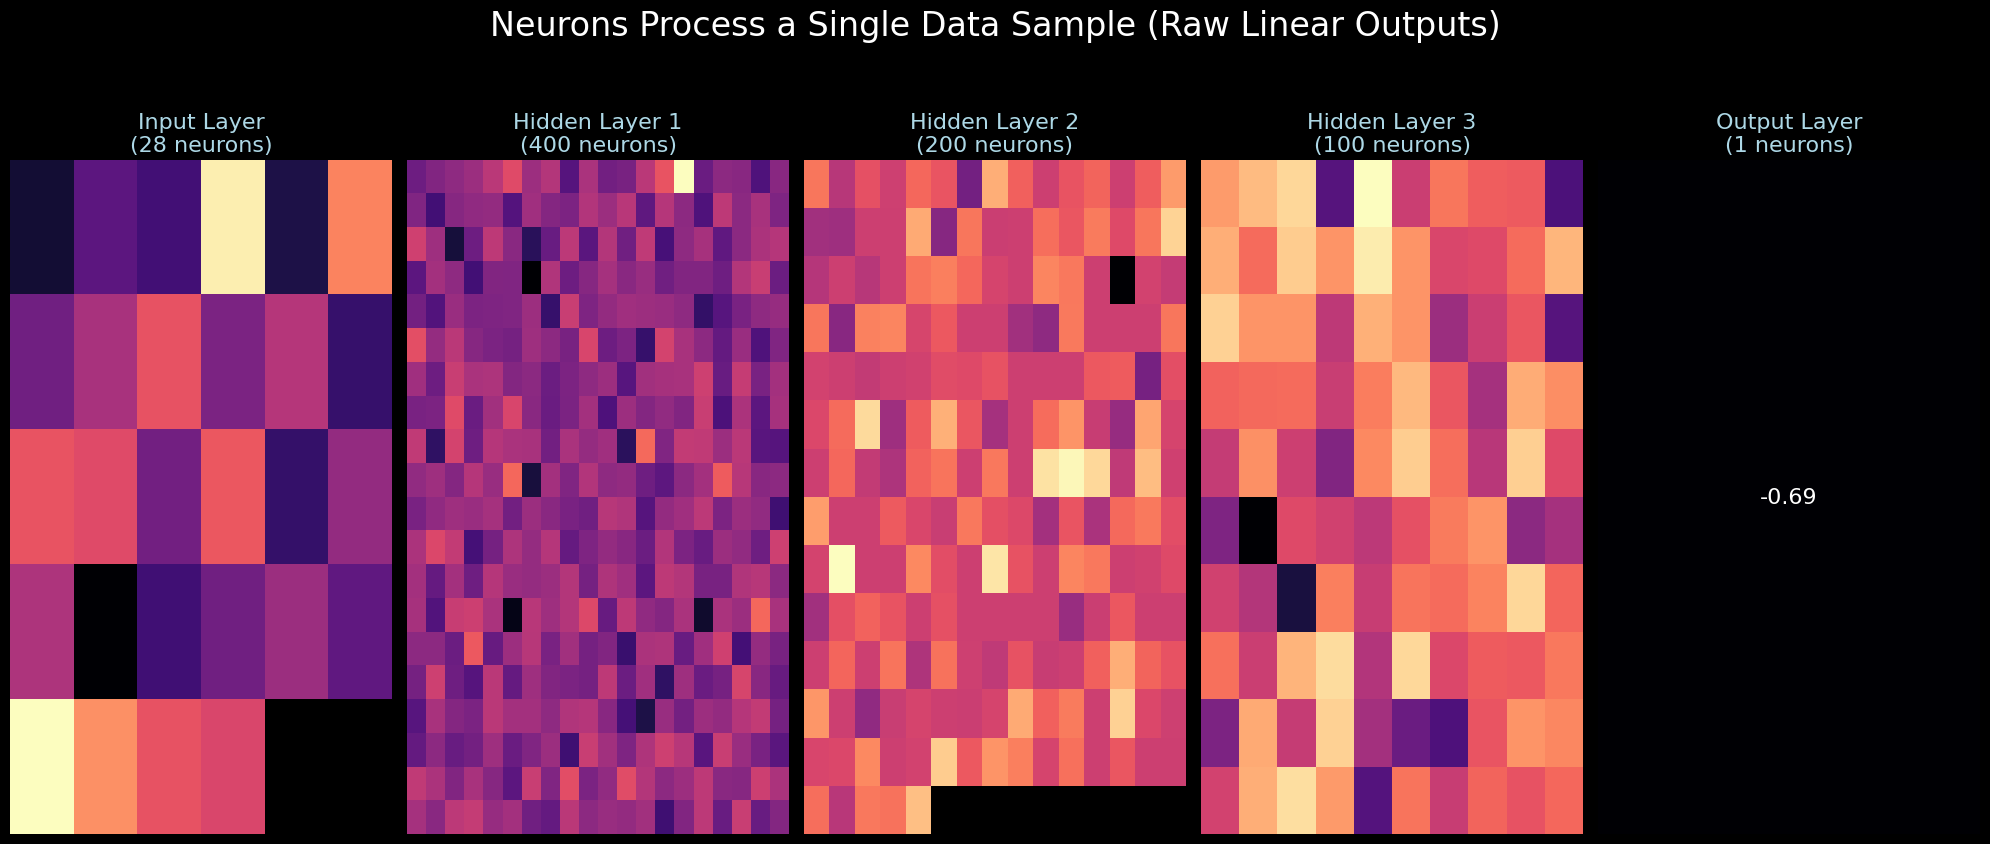

In [43]:
single_sample = x_val_scaled[0]
layer_outputs = [single_sample] 
current_output = single_sample
for i in range(len(mlp_model_training.coefs_) - 1):
    weight = mlp_model_training.coefs_[i]
    bias = mlp_model_training.intercepts_[i]
    current_output = np.dot(current_output, weight) + bias
    layer_outputs.append(current_output.flatten())
final_weight = mlp_model_training.coefs_[-1]
final_bias = mlp_model_training.intercepts_[-1]
final_output = np.dot(current_output, final_weight) + final_bias
layer_outputs.append(final_output.flatten())
layer_names = ['Input Layer', 'Hidden Layer 1', 'Hidden Layer 2', 'Hidden Layer 3', 'Output Layer']
plt.style.use('dark_background')
fig, axes = plt.subplots(nrows=1, ncols=len(layer_outputs), figsize=(20, 8))
fig.suptitle('Neurons Process a Single Data Sample (Raw Linear Outputs)', fontsize=24, color='white', y=1.05)
for i, ax in enumerate(axes):
    out_vals = layer_outputs[i]
    length = len(out_vals)
    
    if length == 1:
        grid = out_vals.reshape(1, 1)
        sns.heatmap(grid, ax=ax, cmap='magma', cbar=False, annot=True, fmt=".2f",
                    annot_kws={"size": 16}, xticklabels=False, yticklabels=False)
    else:
        cols = int(np.ceil(np.sqrt(length)))
        rows = int(np.ceil(length / cols))
        padded_out = np.pad(out_vals, (0, rows * cols - length), constant_values=np.nan)
        grid = padded_out.reshape(rows, cols)
        sns.heatmap(grid, ax=ax, cmap='magma', cbar=False, xticklabels=False, yticklabels=False, mask=np.isnan(grid))
    ax.set_title(f"{layer_names[i]}\n({length} neurons)", fontsize=16, color='lightblue')
plt.tight_layout()
plt.savefig('neuron_processing_raw.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


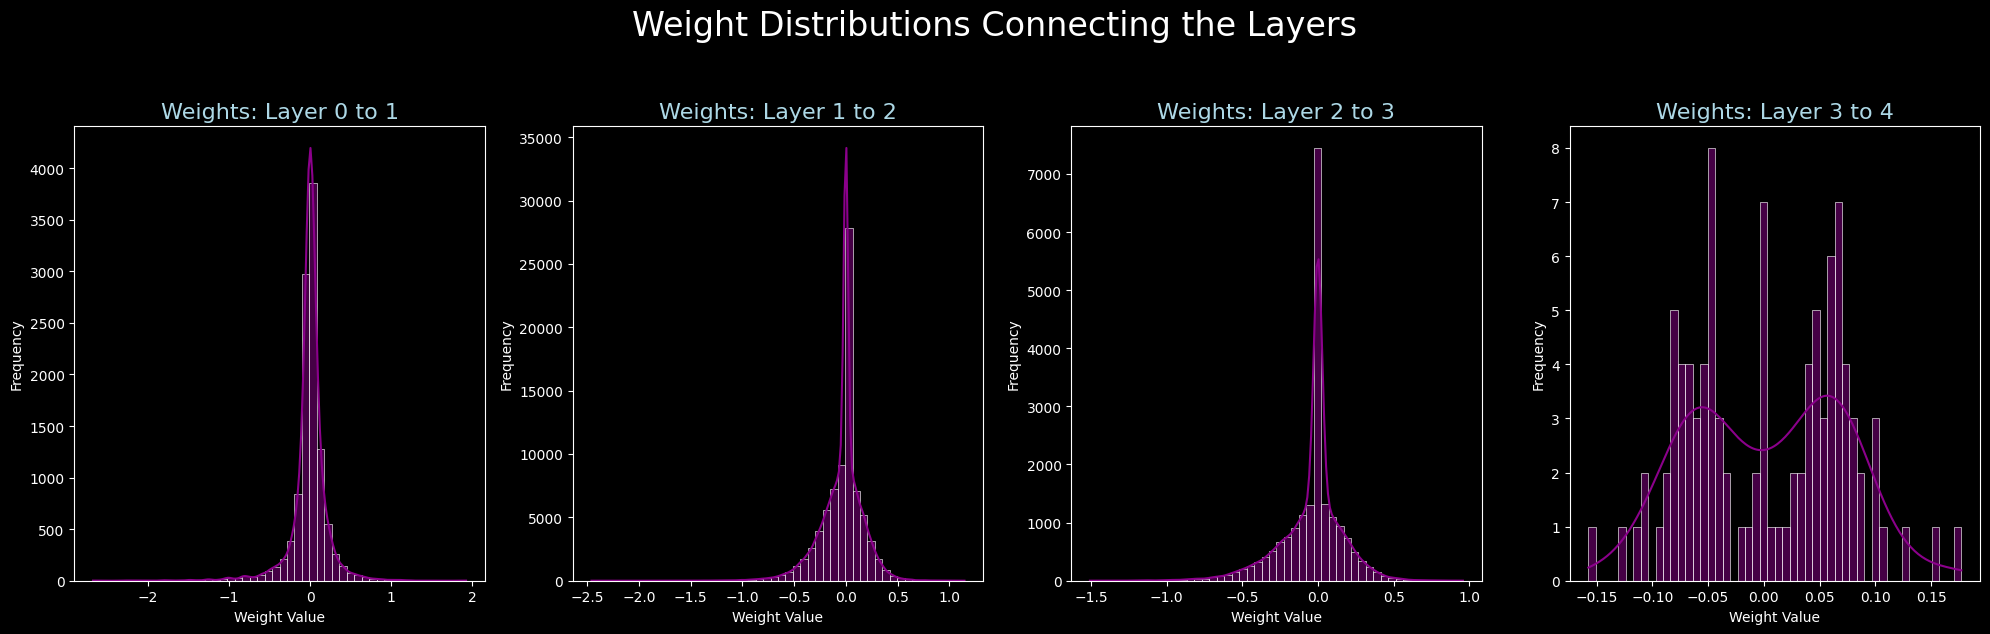

In [44]:
fig2, axes2 = plt.subplots(nrows=1, ncols=len(mlp_model_training.coefs_), figsize=(20, 6))
fig2.suptitle('Weight Distributions Connecting the Layers', fontsize=24, color='white', y=1.05)
for i, ax in enumerate(axes2):
    weights = mlp_model_training.coefs_[i].flatten()
    sns.histplot(weights, bins=50, ax=ax, color='darkmagenta', kde=True)
    ax.set_title(f"Weights: Layer {i} to {i+1}", fontsize=16, color='lightblue')
    ax.set_xlabel("Weight Value", color='white')
    ax.set_ylabel("Frequency", color='white')
    ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('neuron_distributions_by_higgs.png', dpi=300, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()